In [ ]:
import os
import h5py
from H2Crop.H2Crop import H2Crop
import sys
import matplotlib.pyplot as plt
import numpy as np

In [4]:
H2Crop_dataset = H2Crop()

In [5]:
data = H2Crop_dataset.get_random_h5_sample()

if data:
    print(f"\nExtracted Array Shapes:")
    print(f" - Hyperspectral: {data['hyperspectral'].shape}")
    print(f" - Multispectral: {data['multispectral'].shape}")
    print(f" - Labels:        {data['labels'].shape}")
    print(f" - Priors:        {data['prior'].shape}")


Extracted Array Shapes:
 - Hyperspectral: (218, 64, 64)
 - Multispectral: (12, 10, 192, 192)
 - Labels:        (4, 192, 192)
 - Priors:        (4, 192, 192)


In [ ]:
list_files = H2Crop_dataset.get_file_list(from_train=False, limit=1600)
data = H2Crop_dataset.load_h5_data(file_list=list_files, keep_prior=False, data_type="multispectral", detail_layer=0, static=True)

# for sample in data:
#     print(f"\nExtracted Array Shapes:")
#     print(f" - Hyperspectral: {sample['hyperspectral'].shape}")
#     print(f" - Labels:        {sample['labels'].shape}")
#     print('\n')

Successfully sampled 1600 file IDs.


In [ ]:
def check_ram_usage(data, RAM=1):
    tot_bytes = 0

    for sample in data:
        for key,value in sample.items():
            if hasattr(value, 'nbytes'):
                tot_bytes += value.nbytes
    
    RAM_bytes = RAM * 1024 * 1024 * 1024

    print(f'RAM usage (bytes): {tot_bytes} | {RAM_bytes}')
    print(f'RAM usage (%): {round((tot_bytes * 100) / (RAM_bytes), 2)}%')

In [ ]:
check_ram_usage(data=data, RAM=16)

RAM usage (bytes): 2916352000 | 17179869184
RAM usage (%): 16.98%


# PLOT IMAGES

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

def visualize_sample(dataset_dict, detail_layer=0, classes_to_drop=None, external_labels_dict=None):
    """
    Visualizer that respects all detail layers.
    - NO black colors by default.
    - ONLY classes in 'classes_to_drop' are rendered as pure black.
    - Dropped classes are completely hidden from the legend.
    - The legend dynamically shows only the specific classes present in the image.
    """
    # --- 1. Extract and Normalize Sentinel-2 Data ---
    s2_data = dataset_dict['multispectral']
    r_band = s2_data[2, :, :] 
    g_band = s2_data[1, :, :] 
    b_band = s2_data[0, :, :] 
    
    rgb_image = np.stack([r_band, g_band, b_band], axis=-1)
    vmax_norm = np.percentile(rgb_image, 98)
    vmin_norm = np.percentile(rgb_image, 2)
    rgb_normalized = np.clip((rgb_image - vmin_norm) / (vmax_norm - vmin_norm), 0, 1)
    
    # --- 2. Extract the correct Label Layer ---
    labels_raw = dataset_dict['labels']
    if labels_raw.ndim == 3:
        labels_2d = labels_raw[detail_layer].copy()
    else:
        labels_2d = labels_raw.copy()
        
    # --- 3. Define Class Names Mapping ---
    if detail_layer == 0:
        master_mapping = {
            0: "Background / Unclassified",
            1: "Arable Crops", 
            2: "Permanent Crops", 
            3: "Pastures / Grassland", 
            4: "Unmaintained", 
            5: "Forestry / Trees", 
            6: "Other / Unspecified"
        }
    else:
        # For deeper layers, use the user's dictionary if provided, 
        # otherwise generate generic fallback names
        if external_labels_dict is not None:
            master_mapping = external_labels_dict
        else:
            max_possible = np.max(labels_2d)
            master_mapping = {i: f"Class {i}" for i in range(max_possible + 1)}

    # --- 4. Build the Colormap (The "Paint Palette") ---
    # Find the absolute highest class ID to size the colormap correctly
    max_val = max(np.max(labels_2d), max(master_mapping.keys()))
    
    # Choose a colormap based on how many classes exist
    if max_val <= 10:
        base_cmap = plt.get_cmap('tab10', max_val + 1)
    elif max_val <= 20:
        base_cmap = plt.get_cmap('tab20', max_val + 1)
    else:
        # 'turbo' is excellent for maintaining contrast with 30-80+ classes
        base_cmap = plt.get_cmap('turbo', max_val + 1) 
        
    # Extract the RGBA colors into a list
    color_list = base_cmap(np.arange(max_val + 1))
    
    # If classes_to_drop is provided, literally paint those specific IDs black.
    # We DO NOT alter the pixel numbers in labels_2d!
    if classes_to_drop is not None:
        for c in classes_to_drop:
            if c <= max_val:
                color_list[c] = [0.0, 0.0, 0.0, 1.0] # Pure Black
                
    custom_cmap = mcolors.ListedColormap(color_list)

    # --- 5. Build a Smart Legend ---
    legend_patches = []
    
    # Only pull the classes that actually physically exist inside this specific image patch
    unique_pixels_in_image = np.unique(labels_2d) 
    
    for class_id in unique_pixels_in_image:
        # If this class was dropped, skip putting it in the legend
        if classes_to_drop is not None and class_id in classes_to_drop:
            continue
            
        # Safely get the name, defaulting to "Unknown" if it's somehow missing from the mapping
        class_name = master_mapping.get(class_id, f"Unknown Class {class_id}")
        
        # Add the colored square and the text to the legend
        legend_patches.append(mpatches.Patch(color=custom_cmap(class_id), label=f"{class_id}: {class_name}"))

    # --- 6. Create the Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
    
    axes[0].imshow(rgb_normalized)
    axes[0].set_title('Sentinel-2 Multispectral (True RGB)\nResolution: 192x192 (10m/pixel)')
    axes[0].axis('off')
    
    # Plot using the custom colormap
    im = axes[1].imshow(labels_2d, cmap=custom_cmap, vmin=0, vmax=max_val, interpolation='nearest')
    axes[1].set_title(f'Label Layer {detail_layer}\nResolution: 192x192 (10m/pixel)')
    axes[1].axis('off')
    
    # Add the legend
    axes[1].legend(
        handles=legend_patches, 
        loc='center left', 
        bbox_to_anchor=(1.05, 0.5), 
        title=f"Layer {detail_layer} Classes Present",
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()

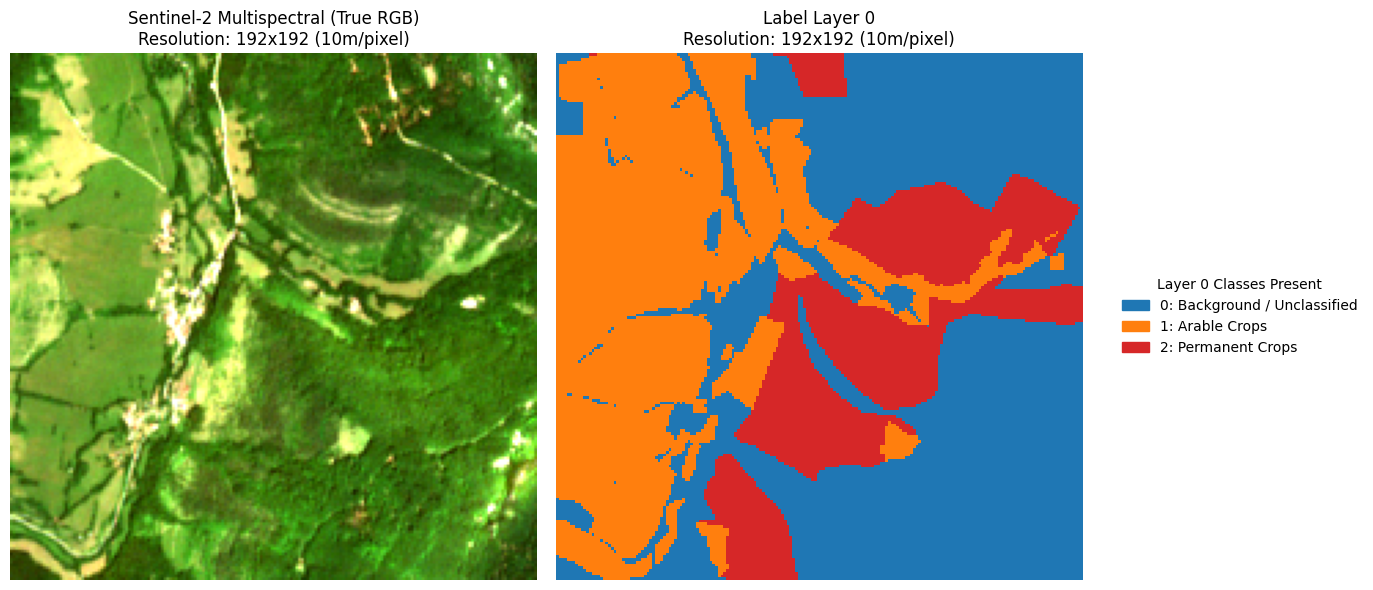

In [64]:
# Assuming you already instantiated your H2Crop class and loaded a sample:
loader = H2Crop()
my_sample = loader.get_random_h5_sample(static=True)
visualize_sample(my_sample, detail_layer=0)